NAV DATA SHAPE : (46000, 3)
SCHEME DATA SHAPE : (40, 19)
INVESTOR DATA SHAPE : (32778, 13)

NAV DATA
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
None

SCHEME DATA
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     f

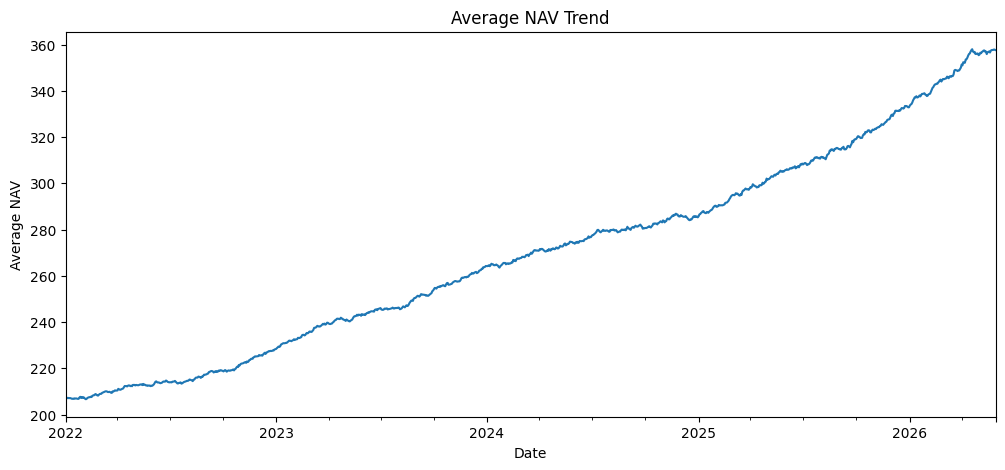

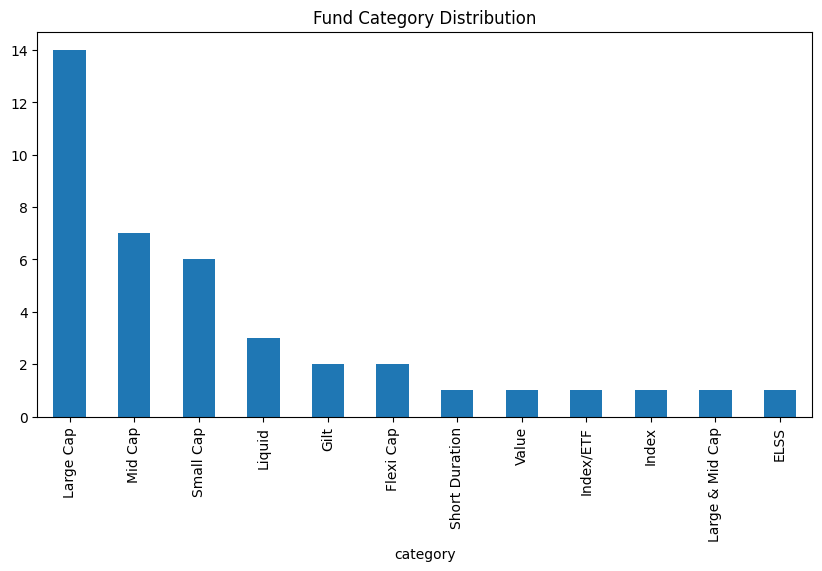

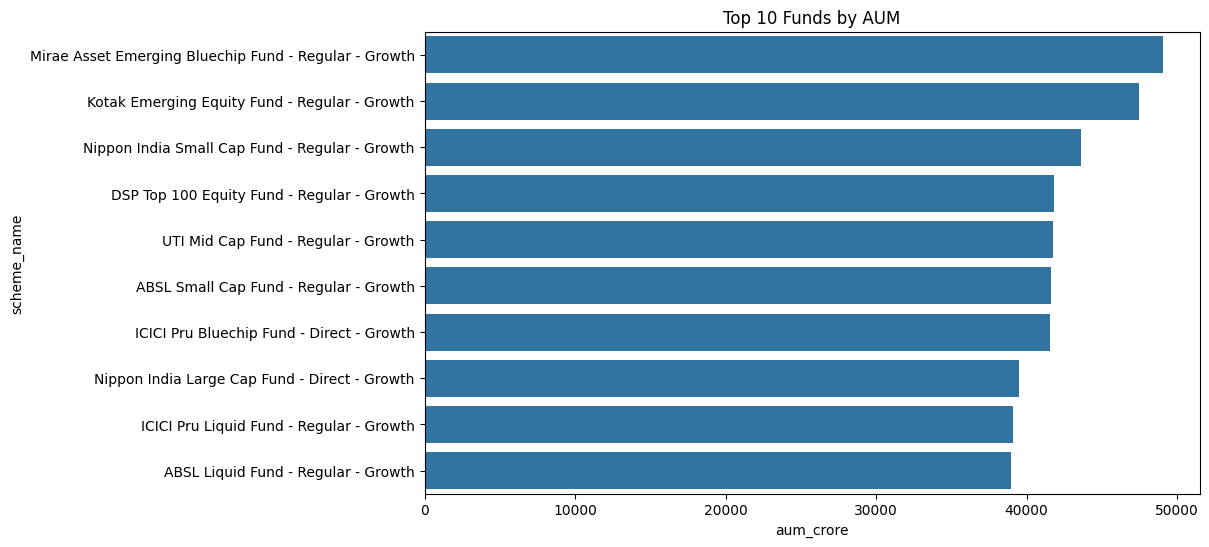

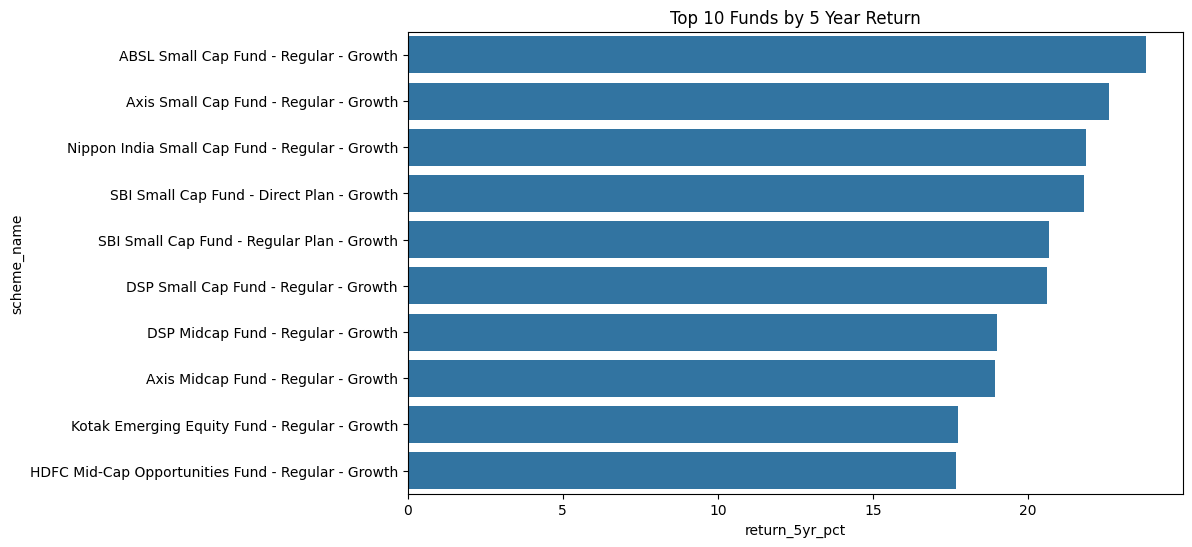

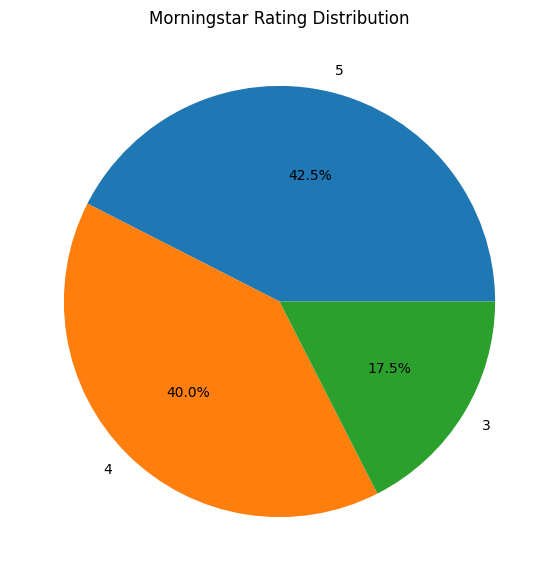

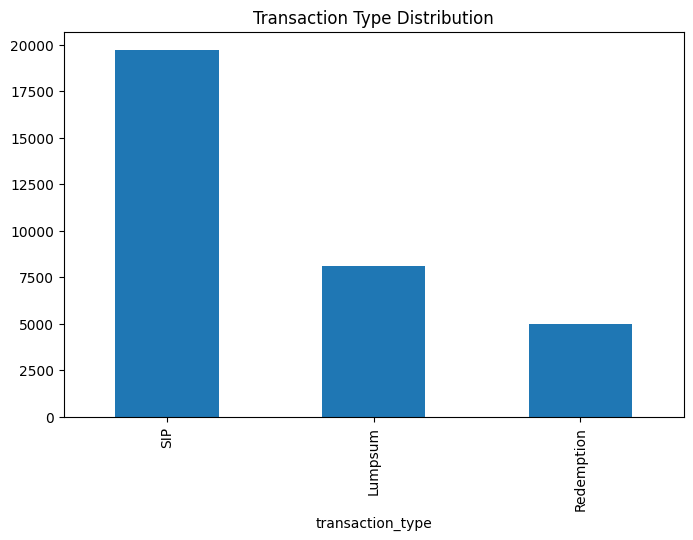

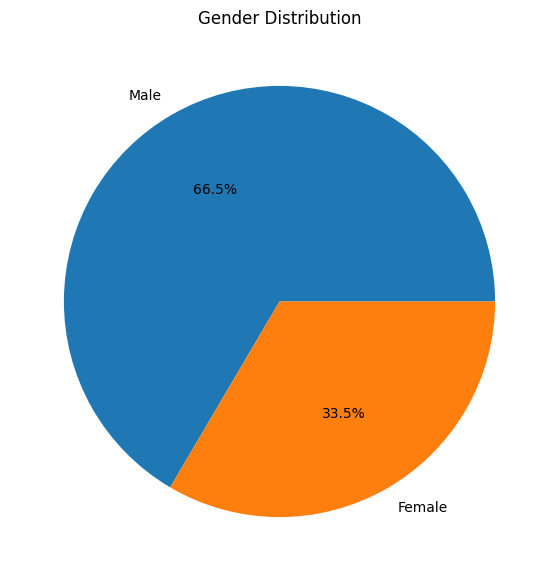

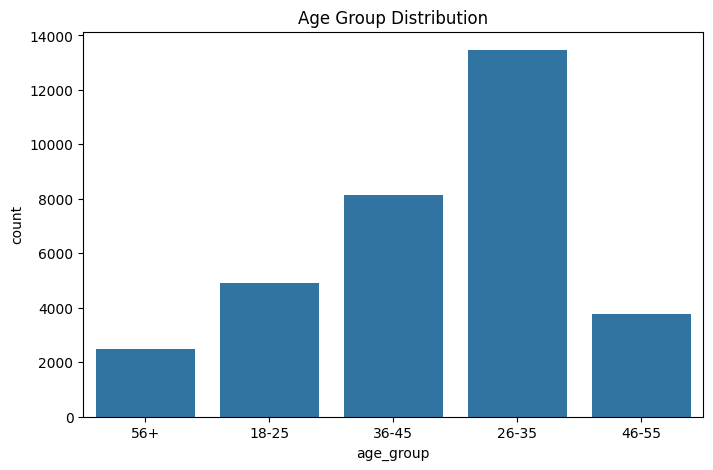

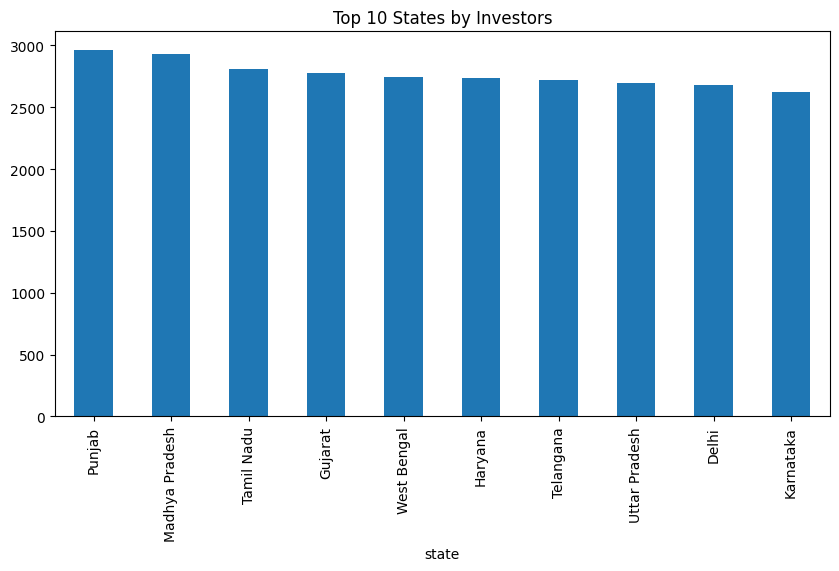

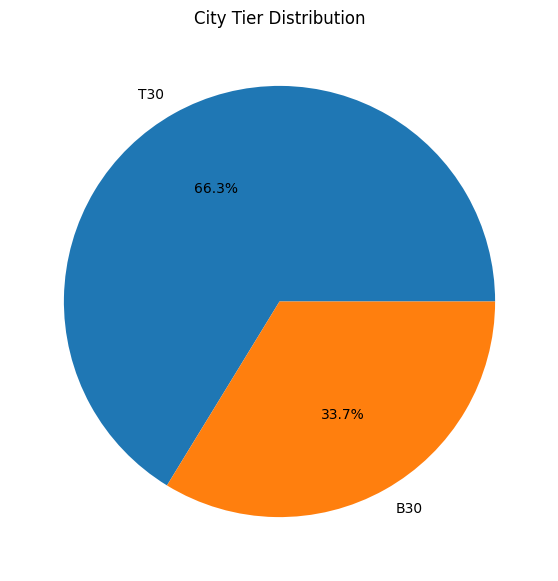

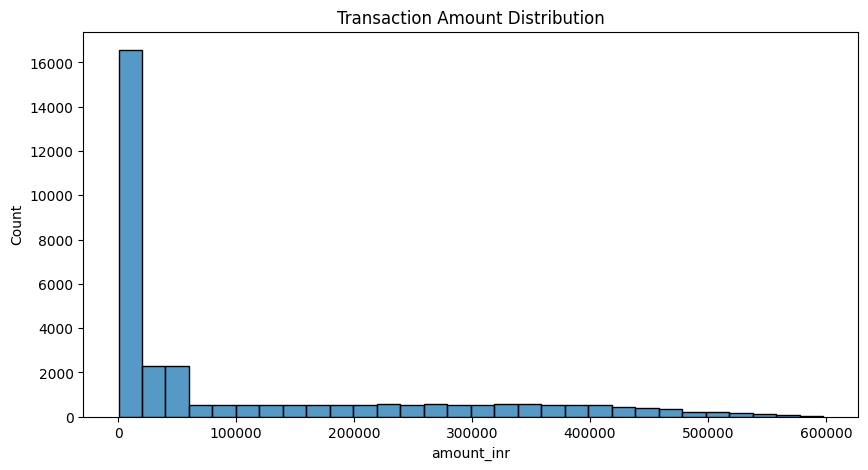

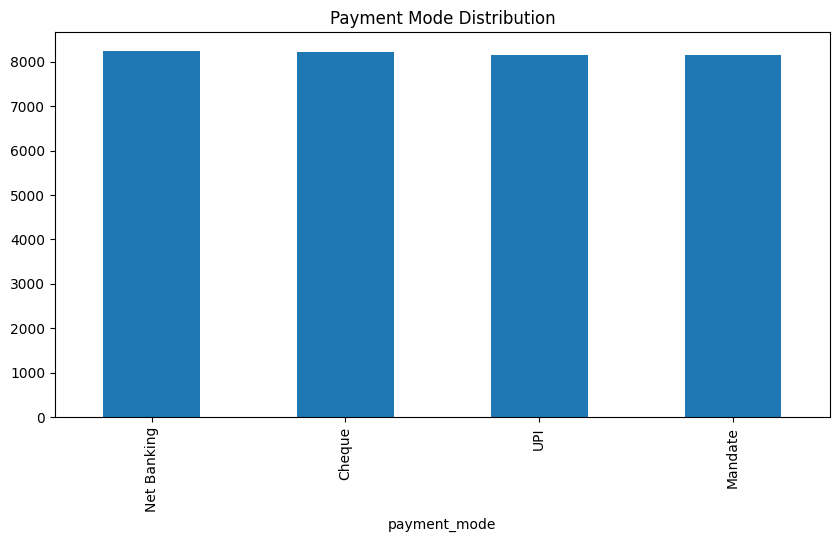

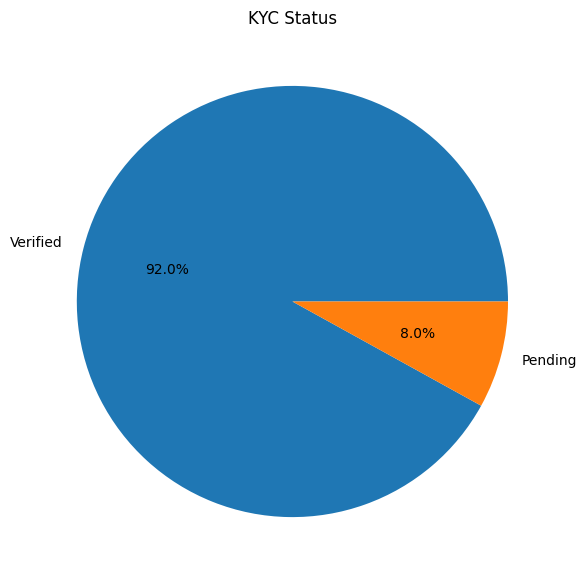

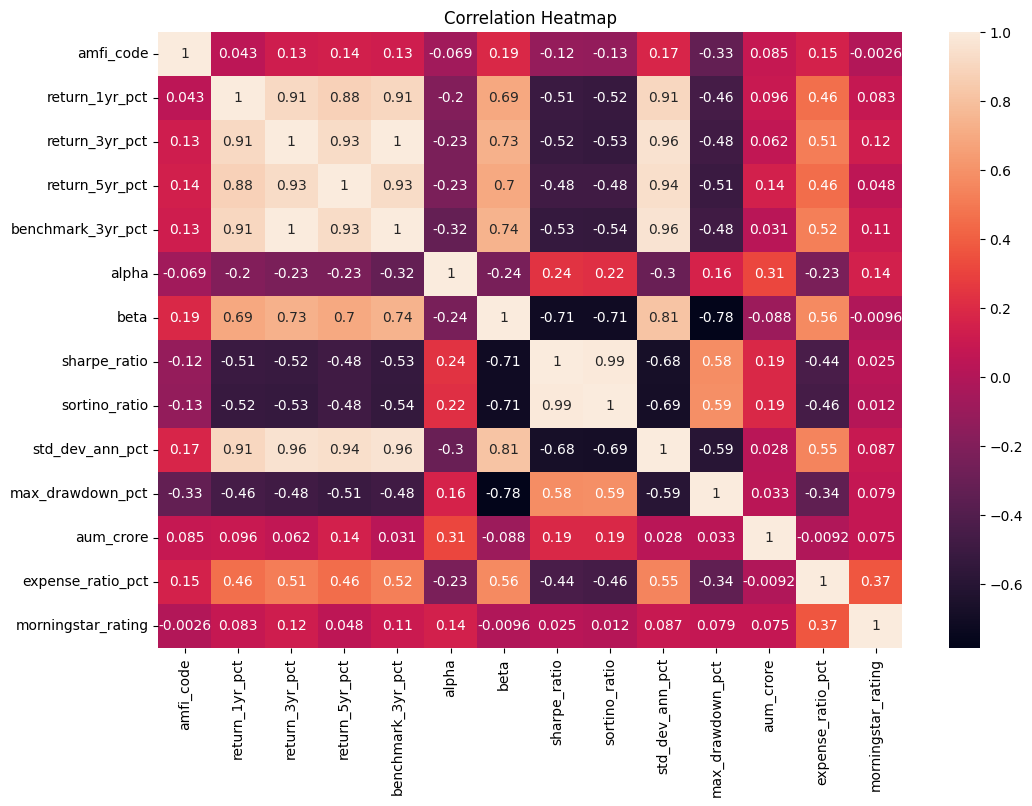

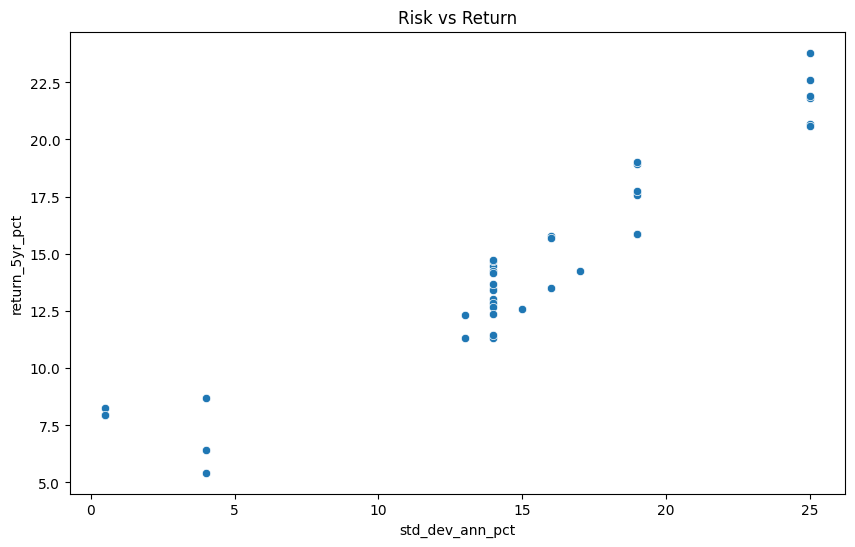


EDA COMPLETED SUCCESSFULLY


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

# ==========================
# LOAD DATASETS
# ==========================

nav = pd.read_csv(
    r"C:\Users\sriha\projects\mutualfundanalytics\data\raw\02_nav_history.csv"
)

scheme = pd.read_csv(
    r"C:\Users\sriha\projects\mutualfundanalytics\data\raw\07_scheme_performance.csv"
)

investor = pd.read_csv(
    r"C:\Users\sriha\projects\mutualfundanalytics\data\raw\08_investor_transactions.csv"
)

print("NAV DATA SHAPE :", nav.shape)
print("SCHEME DATA SHAPE :", scheme.shape)
print("INVESTOR DATA SHAPE :", investor.shape)

# ==========================
# BASIC INFORMATION
# ==========================

print("\nNAV DATA")
print(nav.info())

print("\nSCHEME DATA")
print(scheme.info())

print("\nINVESTOR DATA")
print(investor.info())

# ==========================
# MISSING VALUES
# ==========================

print("\nNAV Missing Values")
print(nav.isnull().sum())

print("\nScheme Missing Values")
print(scheme.isnull().sum())

print("\nInvestor Missing Values")
print(investor.isnull().sum())

# ==========================
# DUPLICATES
# ==========================

print("\nNAV Duplicates :", nav.duplicated().sum())
print("Scheme Duplicates :", scheme.duplicated().sum())
print("Investor Duplicates :", investor.duplicated().sum())

# ==========================
# DATE CONVERSION
# ==========================

nav['date'] = pd.to_datetime(nav['date'])
investor['transaction_date'] = pd.to_datetime(
    investor['transaction_date']
)

# ==========================
# CHART 1
# NAV TREND
# ==========================

plt.figure(figsize=(12,5))

nav.groupby('date')['nav'].mean().plot()

plt.title("Average NAV Trend")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.show()

# ==========================
# CHART 2
# FUND CATEGORY DISTRIBUTION
# ==========================

plt.figure(figsize=(10,5))

scheme['category'].value_counts().plot(
    kind='bar'
)

plt.title("Fund Category Distribution")

plt.show()

# ==========================
# CHART 3
# TOP 10 FUNDS BY AUM
# ==========================

top_aum = scheme.sort_values(
    'aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_aum,
    x='aum_crore',
    y='scheme_name'
)

plt.title("Top 10 Funds by AUM")

plt.show()

# ==========================
# CHART 4
# TOP 10 FUNDS BY 5 YEAR RETURN
# ==========================

top_return = scheme.sort_values(
    'return_5yr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_return,
    x='return_5yr_pct',
    y='scheme_name'
)

plt.title("Top 10 Funds by 5 Year Return")

plt.show()

# ==========================
# CHART 5
# MORNINGSTAR RATING
# ==========================

plt.figure(figsize=(7,7))

scheme['morningstar_rating'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Morningstar Rating Distribution")

plt.show()

# ==========================
# CHART 6
# TRANSACTION TYPES
# ==========================

plt.figure(figsize=(8,5))

investor['transaction_type'].value_counts().plot(
    kind='bar'
)

plt.title("Transaction Type Distribution")

plt.show()

# ==========================
# CHART 7
# GENDER DISTRIBUTION
# ==========================

plt.figure(figsize=(7,7))

investor['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

# ==========================
# CHART 8
# AGE GROUP DISTRIBUTION
# ==========================

plt.figure(figsize=(8,5))

sns.countplot(
    data=investor,
    x='age_group'
)

plt.title("Age Group Distribution")

plt.show()

# ==========================
# CHART 9
# TOP STATES
# ==========================

plt.figure(figsize=(10,5))

investor['state'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 States by Investors")

plt.show()

# ==========================
# CHART 10
# CITY TIER
# ==========================

plt.figure(figsize=(7,7))

investor['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("City Tier Distribution")

plt.show()

# ==========================
# CHART 11
# TRANSACTION AMOUNT
# ==========================

plt.figure(figsize=(10,5))

sns.histplot(
    investor['amount_inr'],
    bins=30
)

plt.title("Transaction Amount Distribution")

plt.show()

# ==========================
# CHART 12
# PAYMENT MODE
# ==========================

plt.figure(figsize=(10,5))

investor['payment_mode'].value_counts().plot(
    kind='bar'
)

plt.title("Payment Mode Distribution")

plt.show()

# ==========================
# CHART 13
# KYC STATUS
# ==========================

plt.figure(figsize=(7,7))

investor['kyc_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("KYC Status")

plt.show()

# ==========================
# CHART 14
# CORRELATION HEATMAP
# ==========================

plt.figure(figsize=(12,8))

corr = scheme.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================
# CHART 15
# RETURN VS RISK
# ==========================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x='std_dev_ann_pct',
    y='return_5yr_pct'
)

plt.title("Risk vs Return")

plt.show()

# ==========================
# SAVE CLEAN DATA
# ==========================

scheme.to_csv(
    "scheme_cleaned.csv",
    index=False
)

print("\nEDA COMPLETED SUCCESSFULLY")

In [ ]:

print(nav_data.head())

NameError: name 'nav_data' is not defined

In [ ]:
rf = 0.065

sharpe_list = []

for fund in nav['amfi_code'].unique():

    r = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    sharpe = ((r.mean() * 252) - rf) / (r.std() * (252 ** 0.5))

    sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=['amfi_code', 'Sharpe_Ratio']
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [ ]:
dd_list = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund]

    running_max = temp['nav'].cummax()

    drawdown = (temp['nav'] - running_max) / running_max

    max_dd = drawdown.min()

    dd_list.append([fund, max_dd])

drawdown_df = pd.DataFrame(
    dd_list,
    columns=['amfi_code', 'Max_Drawdown']
)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [ ]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)

scorecard.head()

,amfi_code,CAGR,Sharpe_Ratio,Max_Drawdown
0,100016,0.026352,-0.201517,-0.247344
1,100025,0.044551,-0.567095,-0.043083
2,100033,0.300997,1.093699,-0.162172
3,101206,0.235205,1.027213,-0.112916
4,101207,0.079331,0.162661,-0.354469


In [ ]:
scorecard['CAGR_Rank'] = scorecard['CAGR'].rank(ascending=False)

scorecard['Sharpe_Rank'] = scorecard['Sharpe_Ratio'].rank(ascending=False)

scorecard['Drawdown_Rank'] = scorecard['Max_Drawdown'].rank(ascending=False)

scorecard['Final_Score'] = (
    scorecard['CAGR_Rank']
    + scorecard['Sharpe_Rank']
    + scorecard['Drawdown_Rank']
)

scorecard.sort_values('Final_Score').head(10)

,amfi_code,CAGR,Sharpe_Ratio,Max_Drawdown,CAGR_Rank,Sharpe_Rank,Drawdown_Rank,Final_Score
34,148567,0.309499,1.448291,-0.112657,5.0,1.0,8.0,14.0
30,120843,0.308833,1.306744,-0.129740,6.0,2.0,13.0,21.0
36,148569,0.319245,1.234930,-0.163967,4.0,3.0,21.0,28.0
3,101206,0.235205,1.027213,-0.112916,12.0,9.0,9.0,30.0
19,119551,0.257849,1.208267,-0.150124,10.0,4.0,17.0,31.0
25,120505,0.328016,1.180101,-0.181885,1.0,5.0,25.0,31.0
2,100033,0.300997,1.093699,-0.162172,7.0,7.0,20.0,34.0
24,120504,0.232774,1.026524,-0.125883,13.0,10.0,12.0,35.0
38,149323,0.295581,1.132122,-0.172481,8.0,6.0,22.0,36.0
20,119552,0.215080,0.953279,-0.118035,15.0,12.0,11.0,38.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("Libraries loaded successfully")

SyntaxError: invalid syntax (3764951877.py, line 1)

In [ ]:
import os

print(os.listdir())

In [2]:
import os

print(os.listdir())

['cagr_results.csv', 'drawdown_results.csv', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'notebooks.zip.zip', 'Performance_Analytics.ipynb', 'scheme_cleaned.csv', 'sharpe_results.csv']


In [7]:
import pandas as pd

scorecard = pd.read_csv("fund_scorecard.csv")
print(scorecard.head())

   amfi_code      CAGR  Sharpe_Ratio  Max_Drawdown  CAGR_Rank  Sharpe_Rank  \
0     100016  0.026352     -0.201517     -0.247344       37.0         35.0   
1     100025  0.044551     -0.567095     -0.043083       36.0         39.0   
2     100033  0.300997      1.093699     -0.162172        7.0          7.0   
3     101206  0.235205      1.027213     -0.112916       12.0          9.0   
4     101207  0.079331      0.162661     -0.354469       27.0         28.0   

   Drawdown_Rank  Final_Score  
0           34.0        106.0  
1            4.0         79.0  
2           20.0         34.0  
3            9.0         30.0  
4           38.0         93.0  


In [8]:
import os

for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

cagr_results.csv
drawdown_results.csv
fund_scorecard.csv
scheme_cleaned.csv
sharpe_results.csv


In [10]:
import pandas as pd

scorecard = pd.read_csv("fund_scorecard.csv")

top10 = scorecard.sort_values("Final_Score").head(10)

print(top10)

    amfi_code      CAGR  Sharpe_Ratio  Max_Drawdown  CAGR_Rank  Sharpe_Rank  \
34     148567  0.309499      1.448291     -0.112657        5.0          1.0   
30     120843  0.308833      1.306744     -0.129740        6.0          2.0   
36     148569  0.319245      1.234930     -0.163967        4.0          3.0   
3      101206  0.235205      1.027213     -0.112916       12.0          9.0   
19     119551  0.257849      1.208267     -0.150124       10.0          4.0   
25     120505  0.328016      1.180101     -0.181885        1.0          5.0   
2      100033  0.300997      1.093699     -0.162172        7.0          7.0   
24     120504  0.232774      1.026524     -0.125883       13.0         10.0   
38     149323  0.295581      1.132122     -0.172481        8.0          6.0   
20     119552  0.215080      0.953279     -0.118035       15.0         12.0   

    Drawdown_Rank  Final_Score  
34            8.0         14.0  
30           13.0         21.0  
36           21.0         28.0 

In [12]:
top10.to_csv("top10_funds.csv", index=False)

print("top10_funds.csv created successfully")

top10_funds.csv created successfully


In [14]:
import os

for file in os.listdir():
    print(file)

cagr_results.csv
drawdown_results.csv
EDA_Analysis.ipynb
fund_scorecard.csv
notebooks.zip.zip
Performance_Analytics.ipynb
scheme_cleaned.csv
sharpe_results.csv
top10_funds.csv


In [16]:
import os

print(os.listdir("data"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data'

In [17]:
import os

print(os.getcwd())


c:\Users\sriha\mutualfundanalytics\notebooks


In [18]:
import os

print(os.listdir("../data"))

['astype_copy.pkl', 'generate_umath_validation_data.cpp', 'proccessed', 'raw', 'recarray_from_file.fits', 'umath-validation-set-arccos.csv', 'umath-validation-set-arccosh.csv', 'umath-validation-set-arcsin.csv', 'umath-validation-set-arcsinh.csv', 'umath-validation-set-arctan.csv', 'umath-validation-set-arctanh.csv', 'umath-validation-set-cbrt.csv', 'umath-validation-set-cos.csv', 'umath-validation-set-cosh.csv', 'umath-validation-set-exp.csv', 'umath-validation-set-exp2.csv', 'umath-validation-set-expm1.csv', 'umath-validation-set-log.csv', 'umath-validation-set-log10.csv', 'umath-validation-set-log1p.csv', 'umath-validation-set-log2.csv', 'umath-validation-set-README.txt', 'umath-validation-set-sin.csv', 'umath-validation-set-sinh.csv', 'umath-validation-set-tan.csv', 'umath-validation-set-tanh.csv']


In [19]:
import os

print(os.listdir(".."))

['.git', 'bluestock_mf.db', 'charts', 'data', 'docs', 'notebooks', 'requirements.txt', 'scripts', 'sql', 'venv']


In [20]:
import os

print(os.listdir("../data/raw"))

['02_nav_history.csv', '07_scheme_performance.csv', '08_investor_transactions.csv']


In [21]:

import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [22]:
import pandas as pd

perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(perf.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [23]:
import pandas as pd

perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

alpha_beta = perf[["amfi_code", "scheme_name", "alpha", "beta"]]

alpha_beta.to_csv("alpha_beta.csv", index=False)

print("alpha_beta.csv created successfully")

alpha_beta.csv created successfully


In [24]:
import os

print(os.listdir())

['alpha_beta.csv', 'cagr_results.csv', 'drawdown_results.csv', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'notebooks.zip.zip', 'Performance_Analytics.ipynb', 'scheme_cleaned.csv', 'sharpe_results.csv', 'top10_funds.csv']


In [25]:
import pandas as pd

scorecard = pd.read_csv("fund_scorecard.csv")

print(scorecard.sort_values("Final_Score").head(5))

    amfi_code      CAGR  Sharpe_Ratio  Max_Drawdown  CAGR_Rank  Sharpe_Rank  \
34     148567  0.309499      1.448291     -0.112657        5.0          1.0   
30     120843  0.308833      1.306744     -0.129740        6.0          2.0   
36     148569  0.319245      1.234930     -0.163967        4.0          3.0   
3      101206  0.235205      1.027213     -0.112916       12.0          9.0   
19     119551  0.257849      1.208267     -0.150124       10.0          4.0   

    Drawdown_Rank  Final_Score  
34            8.0         14.0  
30           13.0         21.0  
36           21.0         28.0  
3             9.0         30.0  
19           17.0         31.0  


benchmark_comparison.png created successfully


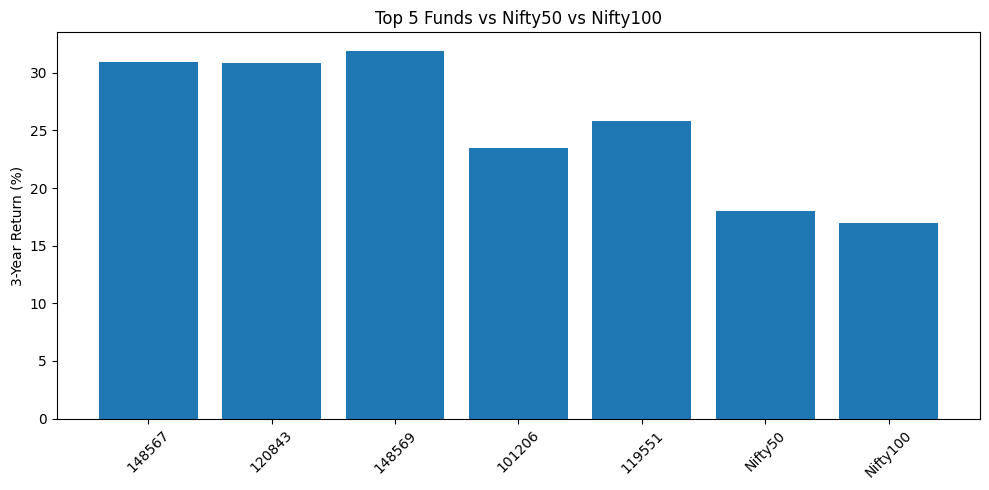

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

top_funds = ["148567", "120843", "148569", "101206", "119551"]

returns = [30.95, 30.88, 31.92, 23.52, 25.78]
nifty50 = 18.0
nifty100 = 17.0

labels = top_funds + ["Nifty50", "Nifty100"]
values = returns + [nifty50, nifty100]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.title("Top 5 Funds vs Nifty50 vs Nifty100")
plt.ylabel("3-Year Return (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("benchmark_comparison.png")

print("benchmark_comparison.png created successfully")

In [27]:
import os
print(os.listdir())

['alpha_beta.csv', 'benchmark_comparison.png', 'cagr_results.csv', 'drawdown_results.csv', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'notebooks.zip.zip', 'Performance_Analytics.ipynb', 'scheme_cleaned.csv', 'sharpe_results.csv', 'top10_funds.csv']
